# Required Packages:

- NumPy: For numerical computing
- Matplotlib: For visualizing solution to ODE and its applications
- Jupyter Lab: For running Jupyter notebooks.

All these packages are mentioned in `requirements.txt`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from solver import ivp
from IPython.display import display, Math

# Modelling population of a species using ODEs:

In any standard calculus course which introduces differential equation, a exponential-growth model for population modelling is presented by using the equation:
$$
\frac{dP}{dt}=rP\qquad\text{Where }P_t\text{ is the population at time }t.\text{ Initial population=}P_0\text{ and }r=\text{ rate of growth of population.}
$$
This equation says that rate of change of population with respect to time is proportional to the population already present. This is indeed true, but it doesn't account for 2 important factors. We will see what those important factors are, but let us first understand, why this model fails. I am not saying that this model is useless, but it works in controlled environments and fails at real-world settings.

## Failure of exponential model:
First we will solve this equation numerically, and take a look at its solution.

Suppose we are modelling a species which has initial population of $200$ and rate of growth $2\%$. $t$ is an appropriate unit of time.

The ODE becomes:
$$
\frac{dP}{dt}=0.02P\qquad(P_0=200)
$$
We will model it from $t=0$ to $t=100$

The solution obtained analytically is: $P(t)=200e^{0.02t}$

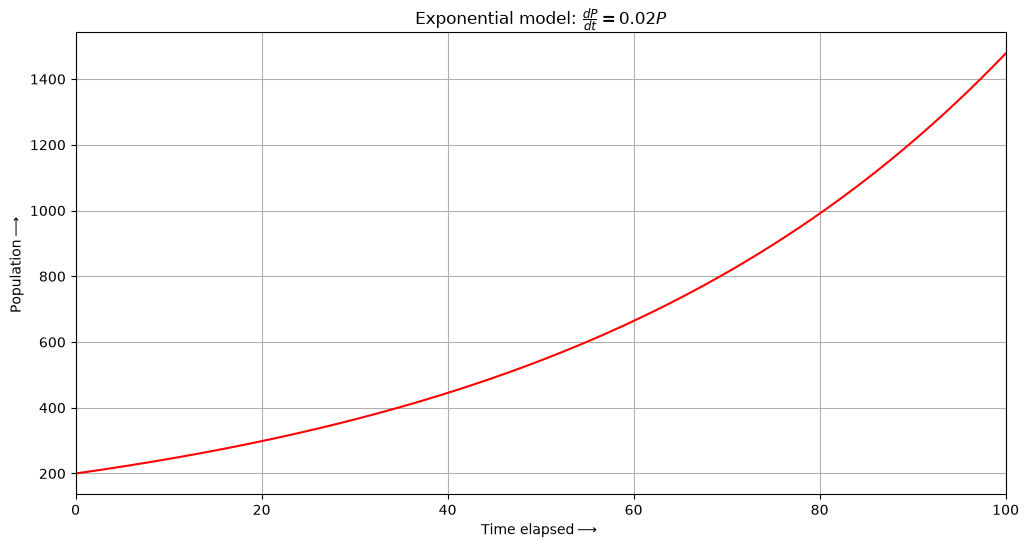

<IPython.core.display.Math object>

In [2]:
exponential = lambda t, P: 0.02*P
a = 0
b = 100
h = 0.01
P0 = 200

data = {
    "func": exponential,
    "initial": P0
}

t, P = ivp.rk4(a, b, h, **data)

plt.figure(figsize=(12, 6))
plt.title("Exponential model: "+r"$\frac{dP}{dt}=0.02P$")
plt.plot(t, P, color="red")
plt.xlim(a, b)
plt.xlabel("Time elapsed"+r"$\longrightarrow$")
plt.ylabel("Population"+r"$\longrightarrow$")
plt.grid()
plt.show()

display(Math(r"\text{Growth in the interested time frame=}"+f"{np.round(100*(P[-1]-P0)/P0, 3)}"+r"\%"))

As we can see that in 100 units of time, the population increased very rapidly. A $638.906\%$ growth!

In real-world scenarios, it is observed by experts that the population caps at one specific value. This occurs because the ecosystem doesn't have unlimited resources. Lab controlled scenarios can simulate infinite resources, but in real-world it is not possible. This specific value at the population is capped is called "Carrying Capacity", represented by $K$. This $K$ is defined as the maximum population that can be contained in a ecosystem for indefinite amount of time. The modified ODE is known as "Logistic Equation" and it is:
$$
\frac{dP}{dt}=rP\left(1-\frac{P}{K}\right)
$$

We will now compare this against the exponential model, then take a look at 3 cases:

1. $P_0<K$
2. $P_0=K$
3. $P_0>K$

Let's assume a species in a ecosystem with $r=0.02$ and $K=1000$. Our study will be from $t=0$ to $t=300$, where $t$ is in units of time.

The ODE becomes:
$$
\frac{dP}{dt}=0.02P\left(1-\frac{P}{1000}\right)
$$

Case 1: $P_0=200$

Case 2: $P_0=1000$

Case 3: $P_0=1200$

Case 1 will be compared with exponential model.

Analytical solution for all cases:
$$\begin{align*}
&\text{Case 1:}
&P(t)=\frac{1000e^{0.02t}}{4+e^{0.02t}}\\
&\text{Case 2:}
&P(t)=1000\\
&\text{Case 3:}
&P(t)=\frac{6000e^{0.02t}}{6e^{0.02t}-1}
\end{align*}$$

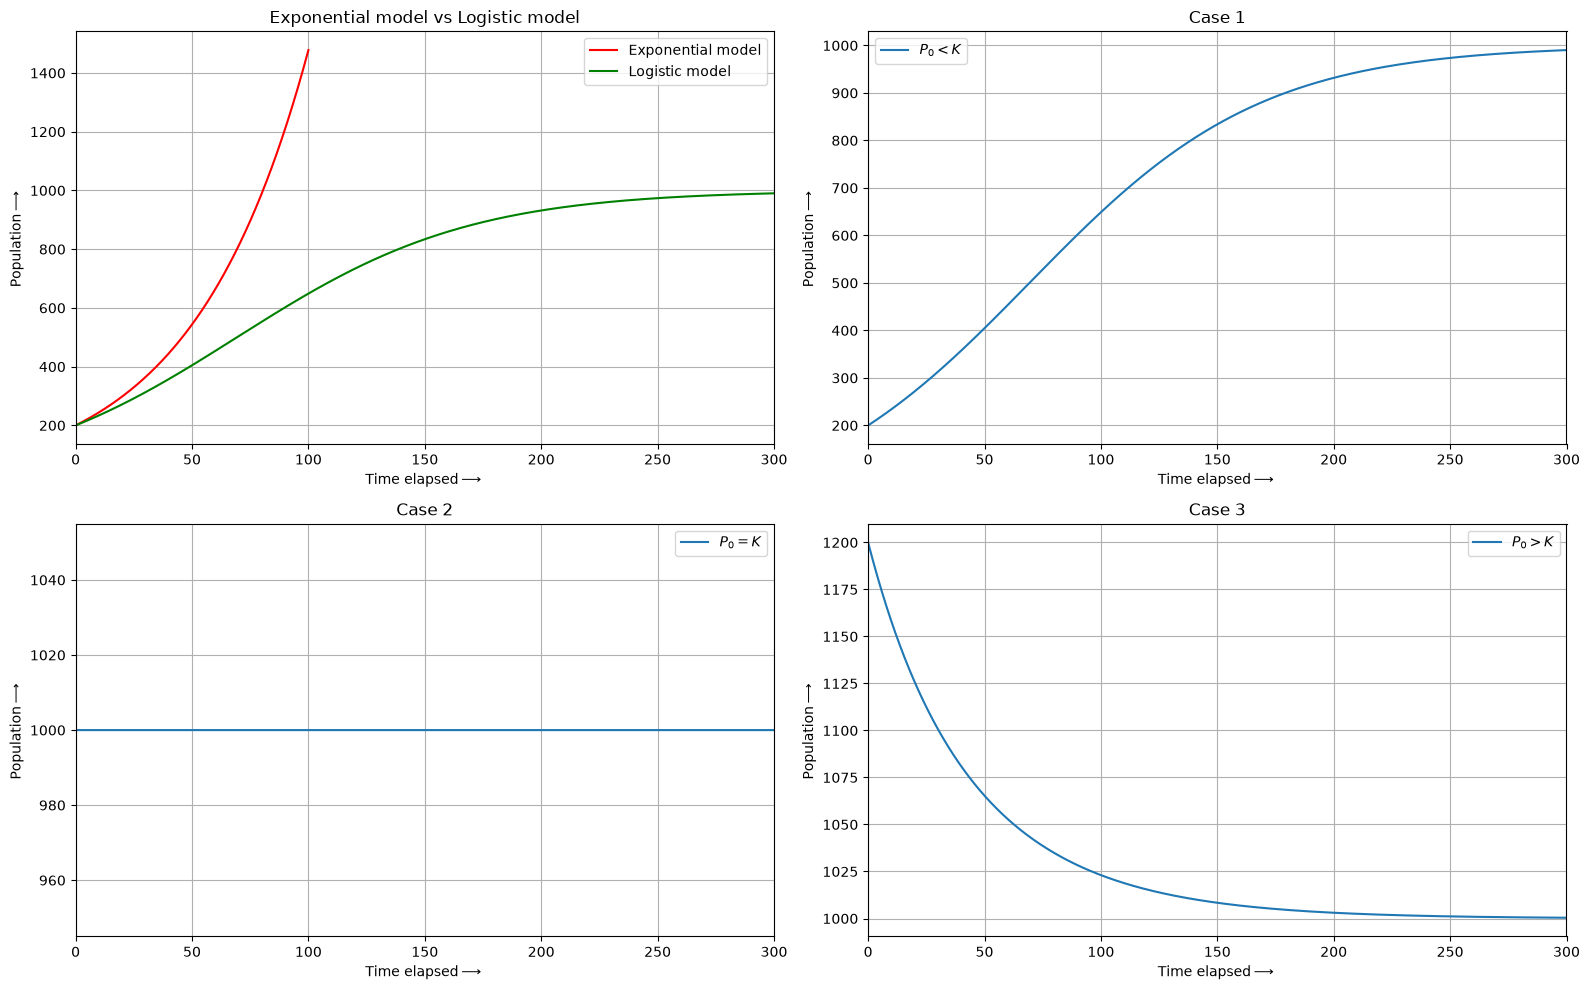

In [3]:
logistic = lambda t, P: 0.02*P*(1-P/1000)
a = 0
b = 300
h = 0.01

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].set_title("Exponential model vs Logistic model")
axes[0, 0].plot(t, P, color="red", label="Exponential model")
t, P = ivp.rk4(a, b, h, func=logistic, initial=200)
axes[0, 0].plot(t, P, color="green", label="Logistic model")

axes[0, 1].set_title("Case 1")
axes[0, 1].plot(t, P, label=r"$P_0<K$")

axes[1, 0].set_title("Case 2")
t, P = ivp.rk4(a, b, h, func=logistic, initial=1000)
axes[1, 0].plot(t, P, label=r"$P_0=K$")

axes[1, 1].set_title("Case 3")
t, P = ivp.rk4(a, b, h, func=logistic, initial=1200)
axes[1, 1].plot(t, P, label=r"$P_0>K$")

for ax in axes.flatten():
    ax.set_xlim(a, b)
    ax.set_xlabel("Time elapsed"+r"$\longrightarrow$")
    ax.set_ylabel("Population"+r"$\longrightarrow$")
    ax.grid()
    ax.legend()

plt.tight_layout()
plt.show()

As expected, over long periods, the population achieves a stable value $K$, this is the equilibrium solution of the logistic equation.

The plot on upper left, shows the difference between exponential and logistic models. I have delibrately, used the previous plot of exponential model, because if we used the model till $t=300$, then predicted population becomes $\approx80,000$, and then we could not see our logistic model plot. On longer periods the exponential model "explodes" giving us unrealistic predictions.

The plot on upper right, shows the case 1 where $P_0<K$. Here we can see how the model approaches $K$ and attains equilibrium.

The plot on lower left, shows the case 2 where $P_0=K$. Here the observation started at carrying capacity, and hence the population graph won't show any change.

The plot on lower right, shows the case 3 where $P_0>K$. Here the ecosystem was already overpopulated, since the ecosystem can only sustain $1000$ number of the particular species, the "extras" perish.

## Failure of logistic model:

Now logistic model does not enforce a lower bound, which means, even if the initial population was just $1$ then also the logistic equation predicts that population will rise. So we need to enforce the lower bound. This phenomenon is called as Allee's effect and the modification is known as Allee's modification.

Here we introduce "Threshold Population" represented by $T$, where $T<K$. The Allee's modification is:
$$
\frac{dP}{dt}=-rP\left(1-\frac{P}{K}\right)\left(1-\frac{P}{T}\right)
$$
At $P_0=T$, the population does not increase. Initial population must be strictly greater than the threshold population for the species to show growth.

Here we will take a look at only 2 cases:

1. $P_0>T$
2. $P_0<T$

Let us assume a species in a ecosystem with $r=0.02$, $K=1000$ and $T=50$. Our study will be from $t=0$ to $t=300$, where $t$ is in units of time.

The ODE becomes:
$$
\frac{dP}{dt}=-0.02P\left(1-\frac{P}{1000}\right)\left(1-\frac{P}{50}\right)
$$
Case 1: $P_0=200$

Case 2: $P_0=40$

Analytical solution for both cases is very difficult to express as explicit functions of $P$ and $t$, hence here, it becomes necessary to solve them numerically.

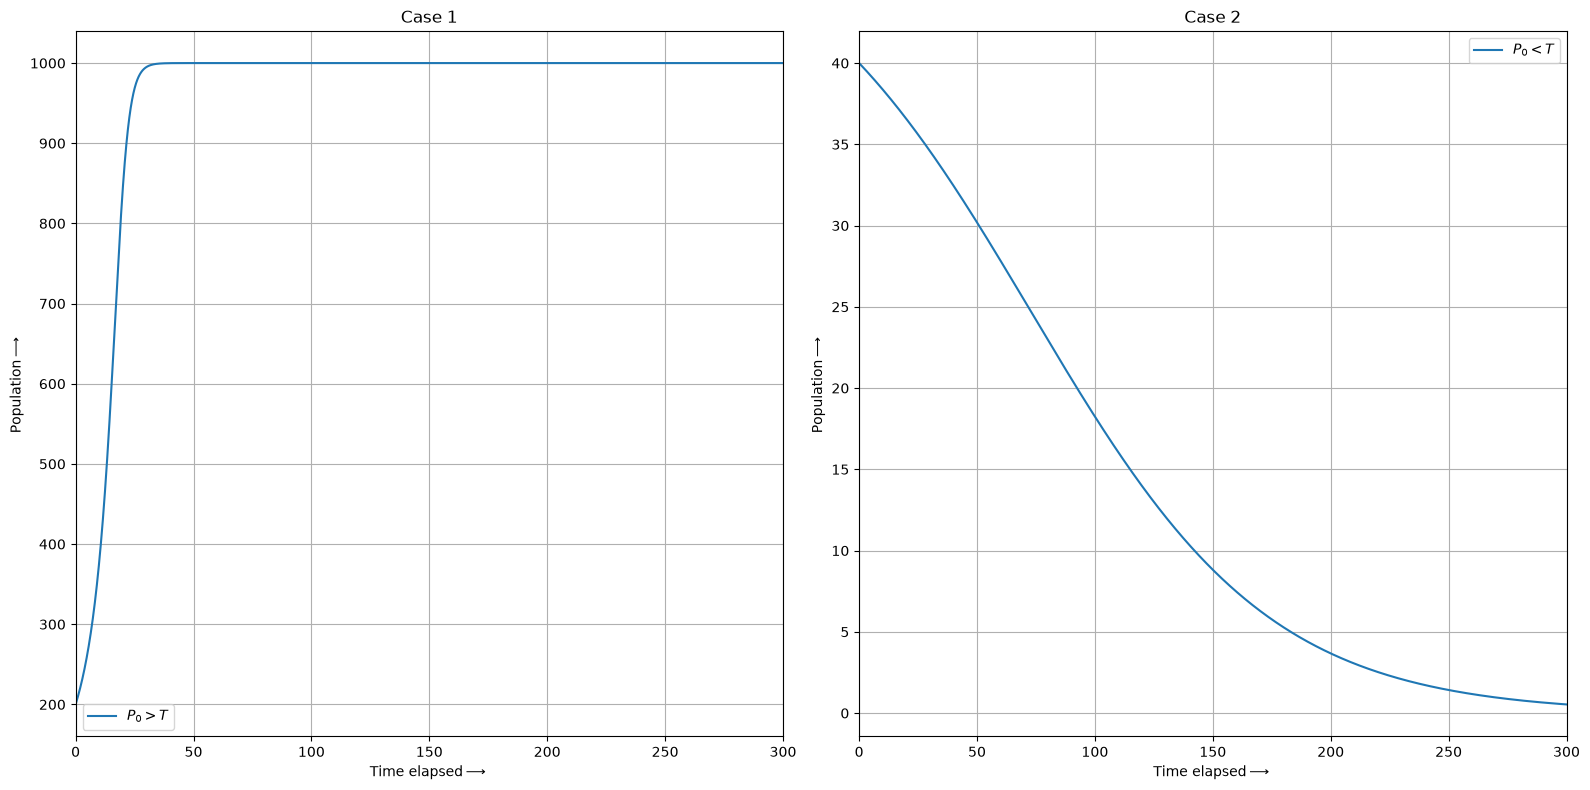

In [4]:
allee = lambda t, P: -0.02*P*(1-P/1000)*(1-P/50)
a = 0
b = 300
h = 0.01

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].set_title("Case 1")
t, P = ivp.rk4(a, b, h, func=allee, initial=200)
axes[0].plot(t, P, label=r"$P_0>T$")

axes[1].set_title("Case 2")
t, P = ivp.rk4(a, b, h, func=allee, initial=40)
axes[1].plot(t, P, label=r"$P_0<T$")

for ax in axes.flatten():
    ax.set_xlim(a, b)
    ax.set_xlabel("Time elapsed"+r"$\longrightarrow$")
    ax.set_ylabel("Population"+r"$\longrightarrow$")
    ax.grid()
    ax.legend()

plt.tight_layout()
plt.show()

The case 1 graph shows that the rate of change is more, but we didn't change $r$, then why? It is the result of the additional term $\frac{P}{T}-1$, this term changed the behaviour of population increase.

The case 2 graph shows as expected that result declines and population will reach to $0$ after a long time.